# Day 4 Assigment Task 1

## 1. Use the California housing dataset and try adding features (like interaction terms between variables) to see if the model's performance improves.

In [2]:
# - Step 0: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

# - Step 1: Load Dataset
california = fetch_california_housing(as_frame=True)
df = california.frame
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [3]:
# - Step 2: Prepare Features and Target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# - Step 3: Add Interaction Features
# Use PolynomialFeatures with degree=2 and interaction_only=True
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_interactions = poly.fit_transform(X)
interaction_feature_names = poly.get_feature_names_out(X.columns)

# Convert to DataFrame for easier inspection
X_interactions_df = pd.DataFrame(X_interactions, columns=interaction_feature_names)
print(X_interactions_df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedInc HouseAge  MedInc AveRooms  ...  AveBedrms Population  \
0    -122.23         341.3332        58.144254  ...            329.666667   
1    -122.22         174.3294        51.785271  ...           2333.485062   
2    -122.24         377.3848        60.150315  ...            532.429379   
3    -122.25         293.4412        32.827897  ...            598.767123   
4    -122.25         200.0024        24.161264  ...            610.810811   

   AveBedrms AveOccup  AveBedrms Latitude  AveBedrms Longitude  \
0            2

In [5]:
# - Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_interactions_df, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (16512, 36)
Testing set shape: (4128, 36)


In [6]:
# - Step 5: Train Linear Regression Model with Interactions
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# - Step 6: Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-Squared: {r2:.4f}")

Mean Squared Error (MSE): 0.4947
R-Squared: 0.6225


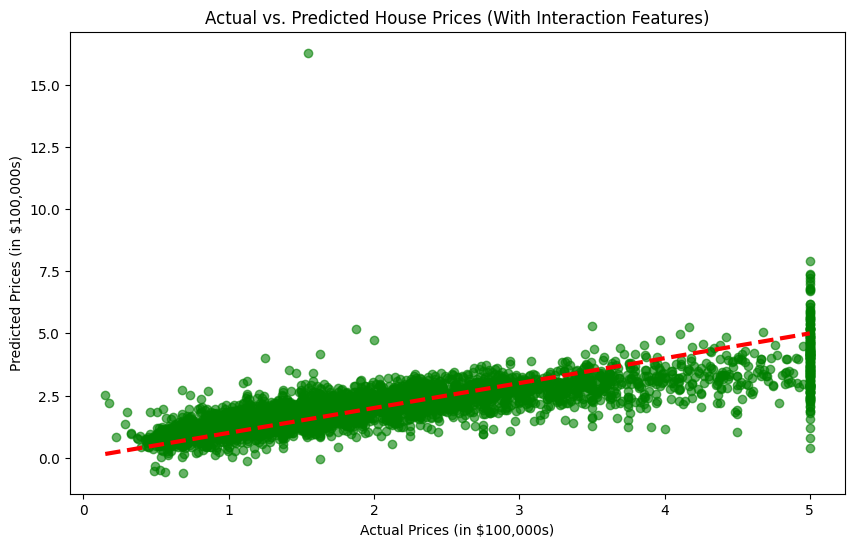

In [9]:
# - Step 7: Visualize Results
# Create a new figure
plt.figure(figsize=(10,6))

# Scatter plot: actual vs predicted
plt.scatter(y_test, y_pred, alpha=0.6, color='green')

# Line for perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3)

# Titles and labels
plt.title('Actual vs. Predicted House Prices (With Interaction Features)')
plt.xlabel('Actual Prices (in $100,000s)')
plt.ylabel('Predicted Prices (in $100,000s)')

# Save the figure BEFORE showing it
plt.savefig("actual_vs_predicted_interactions.png", dpi=300, bbox_inches="tight")

# Show the figure
plt.show()

In [8]:
# - Step 8: Model Coefficients
coefficients = pd.DataFrame(model.coef_, interaction_feature_names, columns=['Coefficient'])
print(coefficients)

                      Coefficient
MedInc                  -9.194925
HouseAge                -0.978353
AveRooms                 4.720220
AveBedrms              -22.991106
Population              -0.001349
AveOccup                 1.301899
Latitude                 0.832330
Longitude                0.003392
MedInc HouseAge          0.001400
MedInc AveRooms         -0.009513
MedInc AveBedrms         0.088690
MedInc Population        0.000062
MedInc AveOccup         -0.001279
MedInc Latitude         -0.127963
MedInc Longitude        -0.117441
HouseAge AveRooms       -0.002210
HouseAge AveBedrms       0.018647
HouseAge Population      0.000002
HouseAge AveOccup       -0.003278
HouseAge Latitude       -0.012109
HouseAge Longitude      -0.011813
AveRooms AveBedrms      -0.000997
AveRooms Population     -0.000070
AveRooms AveOccup        0.023923
AveRooms Latitude        0.071658
AveRooms Longitude       0.061070
AveBedrms Population     0.000542
AveBedrms AveOccup      -0.131740
AveBedrms Lati